In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Demo_Resume_Dataset_30.xlsx to Demo_Resume_Dataset_30.xlsx


In [ ]:
df = pd.read_excel("Demo_Resume_Dataset_30.xlsx")
df.head()

,Candidate ID,Candidate Name,Category,Skills,Experience,Education,Resume
0,C001,Rahul Sharma,Data Science,"Python, SQL, Pandas, NumPy, Machine Learning, ...",ML Intern (1 year),B.Tech CSE,"B.Tech CSE. Skilled in Python, SQL, Pandas, Nu..."
1,C002,Priya Reddy,Data Science,"Python, SQL, Pandas, NumPy, Machine Learning, ...",Data Analyst Intern (6 months),B.Tech CSE,"B.Tech CSE. Skilled in Python, SQL, Pandas, Nu..."
2,C003,Arjun Kumar,Data Science,"Python, SQL, Pandas, NumPy, Machine Learning, ...",Data Analyst Intern (6 months),B.Tech CSE,"B.Tech CSE. Skilled in Python, SQL, Pandas, Nu..."
3,C004,Sneha Patel,Data Science,"Python, SQL, Pandas, NumPy, Machine Learning, ...",ML Intern (1 year),B.Tech CSE,"B.Tech CSE. Skilled in Python, SQL, Pandas, Nu..."
4,C005,Kiran Rao,Data Science,"Python, SQL, Pandas, NumPy, Machine Learning, ...",Data Analyst Intern (6 months),B.Tech CSE,"B.Tech CSE. Skilled in Python, SQL, Pandas, Nu..."


In [ ]:
job_descriptions = {

    "Data Science": """
    Python
    SQL
    Machine Learning
    Deep Learning
    Statistics
    Pandas
    NumPy
    Data Visualization
    Power BI
    Communication
    """,

    "Python Developer": """
    Python
    Django
    Flask
    SQL
    APIs
    Git
    OOP
    Problem Solving
    """,

    "Java Developer": """
    Java
    Spring Boot
    SQL
    JDBC
    Hibernate
    REST API
    Git
    OOP
    """,

    "HR": """
    Recruitment
    Payroll
    Employee Relations
    Hiring
    Talent Acquisition
    Communication
    """
}

In [ ]:
def screen_resume():

    job_role = input("Enter Job Role: ")

    # Find Job Description
    job_description = None

    for key in job_descriptions:
        if key.lower() == job_role.lower():
            job_description = job_descriptions[key]
            selected_role = key
            break

    if job_description is None:
        print("Job Category not found.")
        return

    # TF-IDF
    documents = [job_description] + df["Resume"].tolist()

    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(documents)

    similarity_scores = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:]
    )

    df["Match Percentage"] = (
        similarity_scores.flatten()*100
    ).round(2)

    # Sort Candidates
    ranked_candidates = df.sort_values(
        by="Match Percentage",
        ascending=False
    )

    # Top 10
    top10 = ranked_candidates.head(10)

    print("\n===============================")
    print(" AI RESUME SCREENING SYSTEM")
    print("===============================")

    print("\nSelected Job Role :", selected_role)

    print("\n========== TOP 10 APPLICANTS ==========\n")

    print(top10[
        [
            "Candidate ID",
            "Candidate Name",
            "Category",
            "Match Percentage"
        ]
    ].to_string(index=False))

    # Best Candidate
    best_candidate = ranked_candidates.iloc[0]

    print("\n========== BEST CANDIDATE ==========\n")

    print("Candidate ID :", best_candidate["Candidate ID"])
    print("Candidate Name :", best_candidate["Candidate Name"])
    print("Category :", best_candidate["Category"])
    print("Match Percentage :", best_candidate["Match Percentage"], "%")

    # Graph
    plt.figure(figsize=(10,5))

    plt.bar(
        top10["Candidate Name"],
        top10["Match Percentage"]
    )

    plt.title("Top 10 Applicants for " + selected_role)

    plt.xlabel("Candidate Name")

    plt.ylabel("Match Percentage")

    plt.xticks(rotation=45)

    plt.show()

Enter Job Role: python developer

 AI RESUME SCREENING SYSTEM

Selected Job Role : Python Developer

========== TOP 10 APPLICANTS ==========

Candidate ID Candidate Name         Category  Match Percentage
        C011    Rohit Yadav Python Developer             54.48
        C014  Nisha Agarwal Python Developer             54.48
        C012    Meera Joshi Python Developer             54.34
        C013      Sai Kiran Python Developer             54.34
        C015   Harsha Reddy Python Developer             50.90
        C001   Rahul Sharma     Data Science              7.37
        C009    Vikram Nair     Data Science              7.37
        C010    Pooja Mehta     Data Science              7.37
        C007     Aman Verma     Data Science              7.37
        C004    Sneha Patel     Data Science              7.37

========== BEST CANDIDATE ==========

Candidate ID : C011
Candidate Name : Rohit Yadav
Category : Python Developer
Match Percentage : 54.48 %


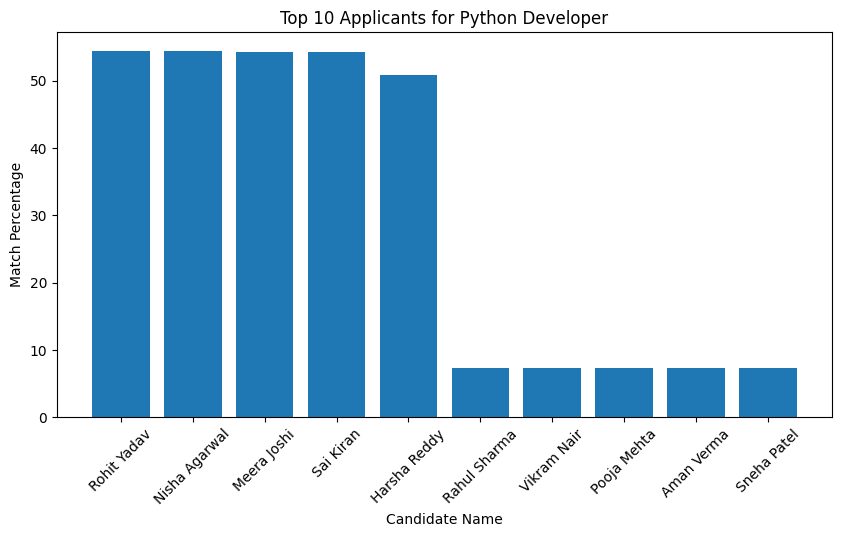

In [ ]:
screen_resume()